In [10]:
#Bike Sharing Kaggle data set https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset/data


In [11]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:

#Loading data
day_df = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/BikeSharing/day.csv')
hour_df = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/BikeSharing/hour.csv')

#1 Data Exploration
print("=" * 60)
print("TOP 5 ROWS")
print("=" * 60)
print(day_df.head())
print(hour_df.head())

print("=" * 60)
print("DATASET ROWS/COLUMNS")
print("=" * 60)
print(f"day.csv:  {day_df.shape[0]} rows x {day_df.shape[1]} columns")
print(f"hour.csv: {hour_df.shape[0]} rows x {hour_df.shape[1]} columns")


print("\n" + "=" * 60)
print("DAY.CSV — DATA TYPES & NON-NULL COUNTS")
print("=" * 60)
print(day_df.info())
 
print("\n" + "=" * 60)
print("HOUR.CSV — DATA TYPES & NON-NULL COUNTS")
print("=" * 60)
print(hour_df.info())



# --- Missing values ---
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print("day.csv missing:\n", day_df.isnull().sum())
print("\nhour.csv missing:\n", hour_df.isnull().sum())
 
# --- Duplicates ---
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"day.csv duplicates:  {day_df.duplicated().sum()}")
print(f"hour.csv duplicates: {hour_df.duplicated().sum()}")
 
# --- Descriptive statistics ---
print("\n" + "=" * 60)
print("DAY.CSV — DESCRIPTIVE STATISTICS")
print("=" * 60)
print(day_df.describe().round(2).to_string())
 
print("\n" + "=" * 60)
print("HOUR.CSV — DESCRIPTIVE STATISTICS")
print("=" * 60)
print(hour_df.describe().round(2).to_string())
 
# --- Unique values for categorical columns ---
print("\n" + "=" * 60)
print("UNIQUE VALUES FOR CATEGORICAL FEATURES")
print("=" * 60)
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in cat_cols:
    print(f"  {col}: {sorted(day_df[col].unique())}")

print("\n" + "=" * 60)
print("REGISTERED VS CASUAL")
print("=" * 60)

total = day_df['cnt'].sum()
casual_pct = day_df['casual'].sum() / total * 100
registered_pct = day_df['registered'].sum() / total * 100
print(f"Casual: {casual_pct:.1f}%")
print(f"Registered: {registered_pct:.1f}%")


# --- Date range ---
print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)
print(f"From: {day_df['dteday'].min()}  To: {day_df['dteday'].max()}")
print(f"Total days: {day_df.shape[0]}")


TOP 5 ROWS
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant     

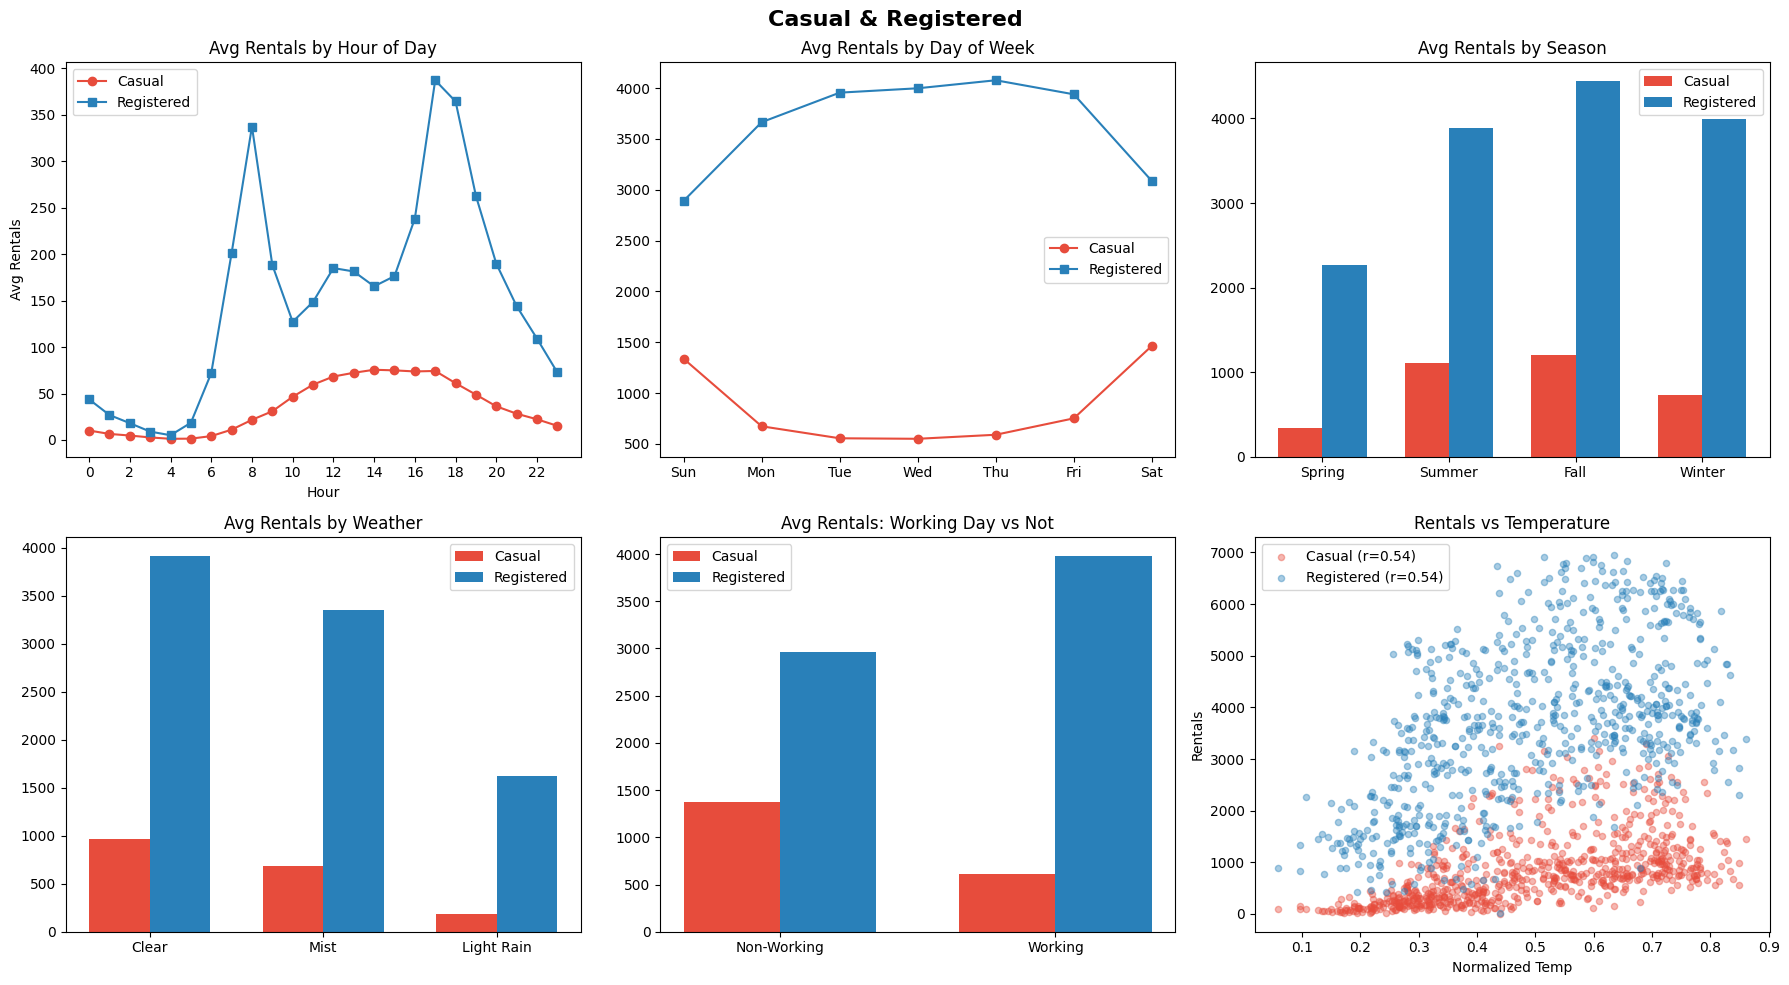


--- Correlation with key features ---
  temp          casual: +0.543   registered: +0.540   diff: 0.003
  atemp         casual: +0.544   registered: +0.544   diff: 0.000
  hum           casual: -0.077   registered: -0.091   diff: 0.014
  windspeed     casual: -0.168   registered: -0.217   diff: 0.050
  workingday    casual: -0.518   registered: +0.304   diff: 0.822
  holiday       casual: +0.054   registered: -0.109   diff: 0.163


In [13]:
#data exploration - visual

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Casual & Registered', fontsize=16, fontweight='bold')


# Hourly pattern
hourly = hour_df.groupby('hr')[['casual', 'registered']].mean()
axes[0, 0].plot(hourly.index, hourly['casual'], 'o-', color='#e74c3c', label='Casual')
axes[0, 0].plot(hourly.index, hourly['registered'], 's-', color='#2980b9', label='Registered')
axes[0, 0].set_title('Avg Rentals by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Avg Rentals')
axes[0, 0].legend()
axes[0, 0].set_xticks(range(0, 24, 2))
 
# Day of week pattern
weekday_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
weekly = day_df.groupby('weekday')[['casual', 'registered']].mean()
axes[0, 1].plot(weekly.index, weekly['casual'], 'o-', color='#e74c3c', label='Casual')
axes[0, 1].plot(weekly.index, weekly['registered'], 's-', color='#2980b9', label='Registered')
axes[0, 1].set_title('Avg Rentals by Day of Week')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(weekday_labels)
axes[0, 1].legend()
 
# Season pattern
season_labels = ['Spring', 'Summer', 'Fall', 'Winter']
seasonal = day_df.groupby('season')[['casual', 'registered']].mean()
x = np.arange(4)
w = 0.35
axes[0, 2].bar(x - w/2, seasonal['casual'], w, color='#e74c3c', label='Casual')
axes[0, 2].bar(x + w/2, seasonal['registered'], w, color='#2980b9', label='Registered')
axes[0, 2].set_title('Avg Rentals by Season')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(season_labels)
axes[0, 2].legend()
 
# Weather impact
weather_labels = ['Clear', 'Mist', 'Light Rain']
weather = day_df.groupby('weathersit')[['casual', 'registered']].mean()
x = np.arange(len(weather))
axes[1, 0].bar(x - w/2, weather['casual'], w, color='#e74c3c', label='Casual')
axes[1, 0].bar(x + w/2, weather['registered'], w, color='#2980b9', label='Registered')
axes[1, 0].set_title('Avg Rentals by Weather')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(weather_labels)
axes[1, 0].legend()
 
# Working day vs non-working day
wd = day_df.groupby('workingday')[['casual', 'registered']].mean()
x = np.arange(2)
axes[1, 1].bar(x - w/2, wd['casual'], w, color='#e74c3c', label='Casual')
axes[1, 1].bar(x + w/2, wd['registered'], w, color='#2980b9', label='Registered')
axes[1, 1].set_title('Avg Rentals: Working Day vs Not')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['Non-Working', 'Working'])
axes[1, 1].legend()
 
# Correlation with temp
axes[1, 2].scatter(day_df['temp'], day_df['casual'], alpha=0.4, color='#e74c3c', label=f"Casual (r={day_df['temp'].corr(day_df['casual']):.2f})", s=20)
axes[1, 2].scatter(day_df['temp'], day_df['registered'], alpha=0.4, color='#2980b9', label=f"Registered (r={day_df['temp'].corr(day_df['registered']):.2f})", s=20)
axes[1, 2].set_title('Rentals vs Temperature')
axes[1, 2].set_xlabel('Normalized Temp')
axes[1, 2].set_ylabel('Rentals')
axes[1, 2].legend()
 
plt.tight_layout()
plt.show()


# Print summary stats
print("\n--- Correlation with key features ---")
features = ['temp', 'atemp', 'hum', 'windspeed', 'workingday', 'holiday']
for f in features:
    r_cas = day_df[f].corr(day_df['casual'])
    r_reg = day_df[f].corr(day_df['registered'])
    print(f"  {f:12s}  casual: {r_cas:+.3f}   registered: {r_reg:+.3f}   diff: {abs(r_cas - r_reg):.3f}")
 

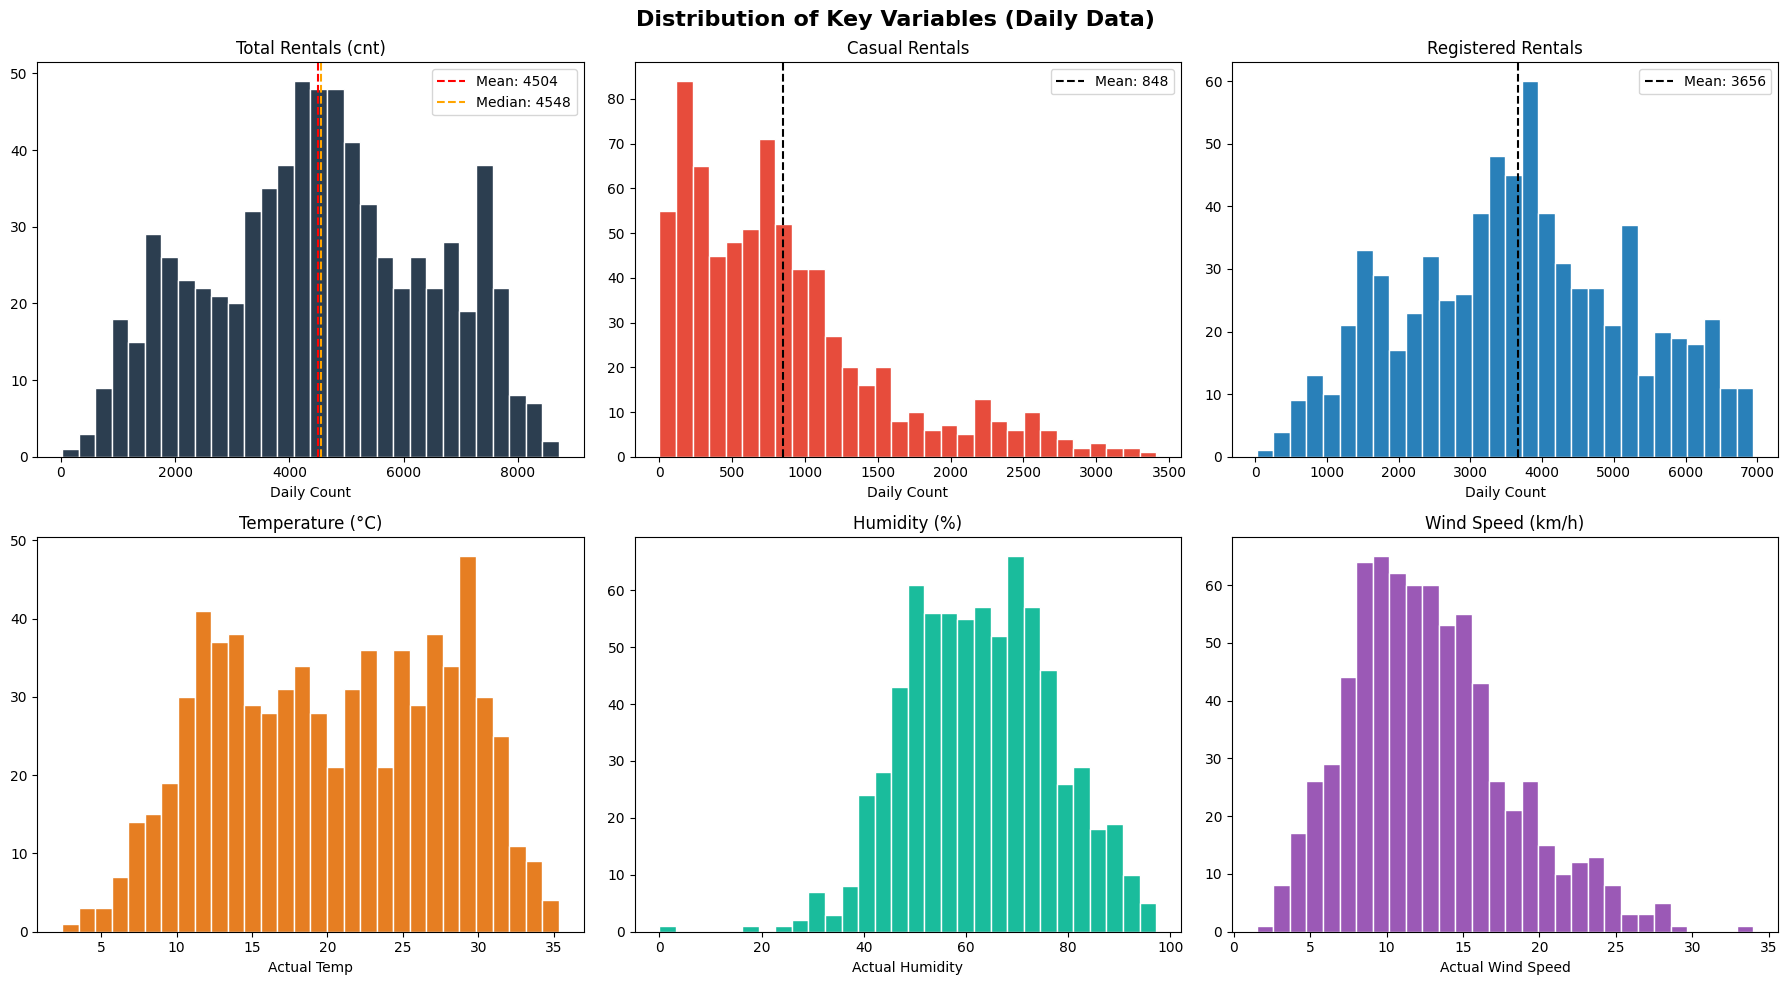

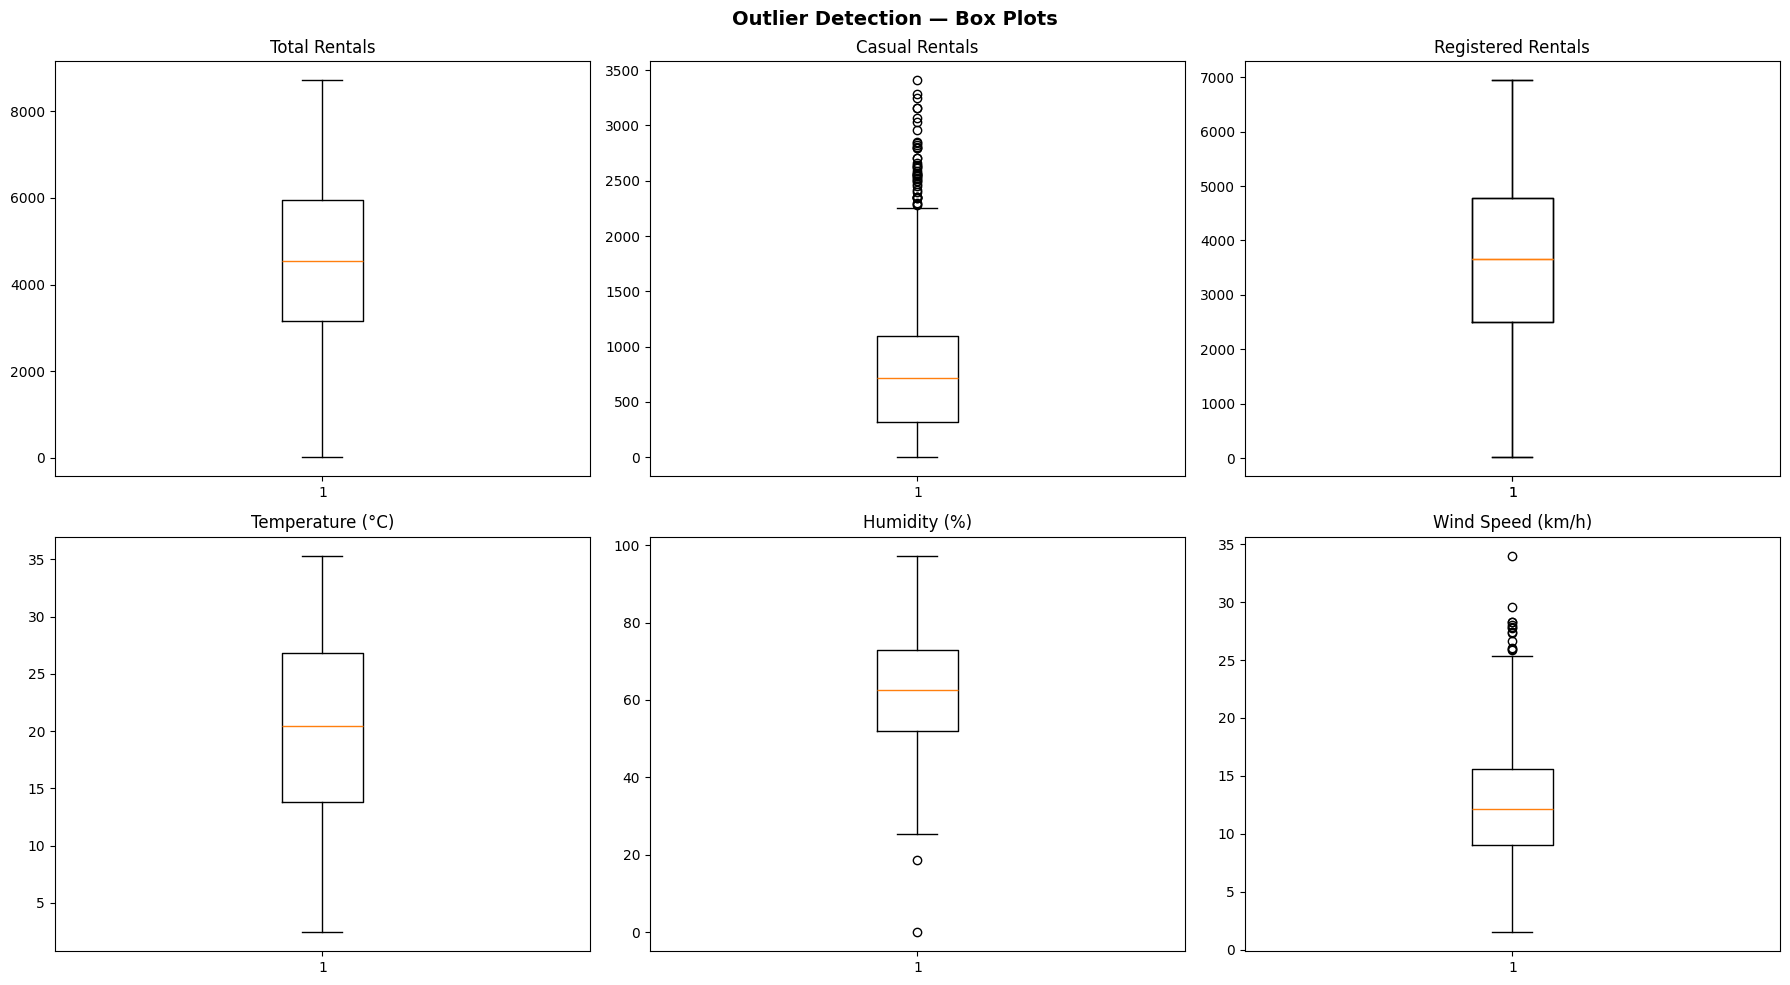

LOOKING AT OUTLIERS WITH INTERQUARTILE RANGE METHOD (IQR Method)

  totalRentals:
    Q1=3152.0  Q3=5956.0  IQR=2804.0
    Lower bound=-1054.0  Upper bound=10162.0
    Outliers: 0 (0.0%)

  casual:
    Q1=315.5  Q3=1096.0  IQR=780.5
    Lower bound=-855.2  Upper bound=2266.8
    Outliers: 44 (6.0%)
    Range of outliers: 2282.0 to 3410.0

  registered:
    Q1=2497.0  Q3=4776.5  IQR=2279.5
    Lower bound=-922.2  Upper bound=8195.8
    Outliers: 0 (0.0%)

  humidity:
    Q1=52.0  Q3=73.0  IQR=21.0
    Lower bound=20.5  Upper bound=104.6
    Outliers: 2 (0.3%)
    Range of outliers: 0.0 to 18.8

  windspeed:
    Q1=9.0  Q3=15.6  IQR=6.6
    Lower bound=-0.8  Upper bound=25.5
    Outliers: 13 (1.8%)
    Range of outliers: 25.8 to 34.0

SKEWNESS
  casual: 1.266
  registered: 0.044


In [14]:
#Distribution of target variables ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Variables (Daily Data)', fontsize=16, fontweight='bold')
 
# Target variables
axes[0, 0].hist(day_df['cnt'], bins=30, color='#2c3e50', edgecolor='white')
axes[0, 0].set_title('Total Rentals (cnt)')
axes[0, 0].set_xlabel('Daily Count')
axes[0, 0].axvline(day_df['cnt'].mean(), color='red', linestyle='--', label=f"Mean: {day_df['cnt'].mean():.0f}")
axes[0, 0].axvline(day_df['cnt'].median(), color='orange', linestyle='--', label=f"Median: {day_df['cnt'].median():.0f}")
axes[0, 0].legend()
 
axes[0, 1].hist(day_df['casual'], bins=30, color='#e74c3c', edgecolor='white')
axes[0, 1].set_title('Casual Rentals')
axes[0, 1].set_xlabel('Daily Count')
axes[0, 1].axvline(day_df['casual'].mean(), color='black', linestyle='--', label=f"Mean: {day_df['casual'].mean():.0f}")
axes[0, 1].legend()
 
axes[0, 2].hist(day_df['registered'], bins=30, color='#2980b9', edgecolor='white')
axes[0, 2].set_title('Registered Rentals')
axes[0, 2].set_xlabel('Daily Count')
axes[0, 2].axvline(day_df['registered'].mean(), color='black', linestyle='--', label=f"Mean: {day_df['registered'].mean():.0f}")
axes[0, 2].legend()
 
# Weather features
axes[1, 0].hist(day_df['temp'] * 41, bins=30, color='#e67e22', edgecolor='white')
axes[1, 0].set_title('Temperature (°C)')
axes[1, 0].set_xlabel('Actual Temp')
 
axes[1, 1].hist(day_df['hum'] * 100, bins=30, color='#1abc9c', edgecolor='white')
axes[1, 1].set_title('Humidity (%)')
axes[1, 1].set_xlabel('Actual Humidity')
 
axes[1, 2].hist(day_df['windspeed'] * 67, bins=30, color='#9b59b6', edgecolor='white')
axes[1, 2].set_title('Wind Speed (km/h)')
axes[1, 2].set_xlabel('Actual Wind Speed')
 
plt.tight_layout()
plt.show()
plt.close()
 
# --- Box plots to detect outliers ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Outlier Detection — Box Plots', fontsize=14, fontweight='bold')

axes[0, 0].boxplot(day_df['cnt'])
axes[0, 0].set_title('Total Rentals')

axes[0, 1].boxplot(day_df['casual'])
axes[0, 1].set_title('Casual Rentals')

axes[0, 2].boxplot(day_df['registered'])
axes[0, 2].set_title('Registered Rentals')

axes[0, 2].boxplot(day_df['registered'])
axes[0, 2].set_title('Registered Rentals')
 
axes[1, 0].boxplot(day_df['temp'] * 41)
axes[1, 0].set_title('Temperature (°C)')

axes[1, 1].boxplot(day_df['hum'] * 100)
axes[1, 1].set_title('Humidity (%)')

axes[1, 2].boxplot(day_df['windspeed'] * 67)
axes[1, 2].set_title('Wind Speed (km/h)')
 
plt.tight_layout()
plt.show()
plt.close()
 
# --- Print outlier stats using IQR method ---
print("=" * 60)
print("LOOKING AT OUTLIERS WITH INTERQUARTILE RANGE METHOD (IQR Method)")
print("=" * 60)
 
check_cols = {'totalRentals': day_df['cnt'],
              'casual': day_df['casual'],
              'registered': day_df['registered'],
              'humidity': day_df['hum'] * 100,
              'windspeed': day_df['windspeed'] * 67}
 
for name, data in check_cols.items():
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    print(f"\n  {name}:")
    print(f"    Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}")
    print(f"    Lower bound={lower:.1f}  Upper bound={upper:.1f}")
    print(f"    Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"    Range of outliers: {outliers.min():.1f} to {outliers.max():.1f}")
 
# --- Skewness ---
print("\n" + "=" * 60)
print("SKEWNESS")
print("=" * 60)
for col in ['casual', 'registered']:
    print(f"  {col}: {day_df[col].skew():.3f}")


# Distributions:
# - cnt and registered are symmetric 
# - casual is right-skewed 
# - Temperature shows two humps due to seasons (winter vs summer)

# Box plots:
# - cnt and registered have no outliers
# - casual has 44 outliers (6%) on the high end  (warm days ? )
# - Humidity has 2 low outliers (unusually dry days)
# - Wind speed has 13 outliers (windy days up to 34 km/h)    
 

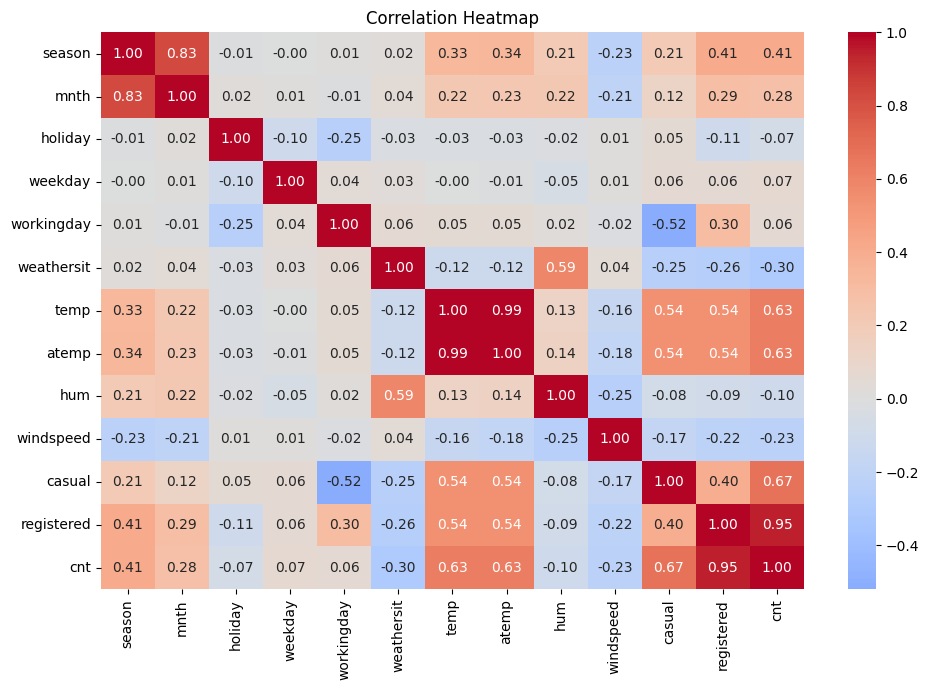

In [15]:
#heatmap
import seaborn as sns

corr_cols = ['season', 'mnth', 'holiday', 'weekday', 'workingday',
             'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
             'casual', 'registered', 'cnt']
corr_matrix = day_df[corr_cols].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# - temp is the strongest weather predictor of rentals (+0.63)
# - workingday has opposite effect: casual (-0.52) vs registered (+0.30)

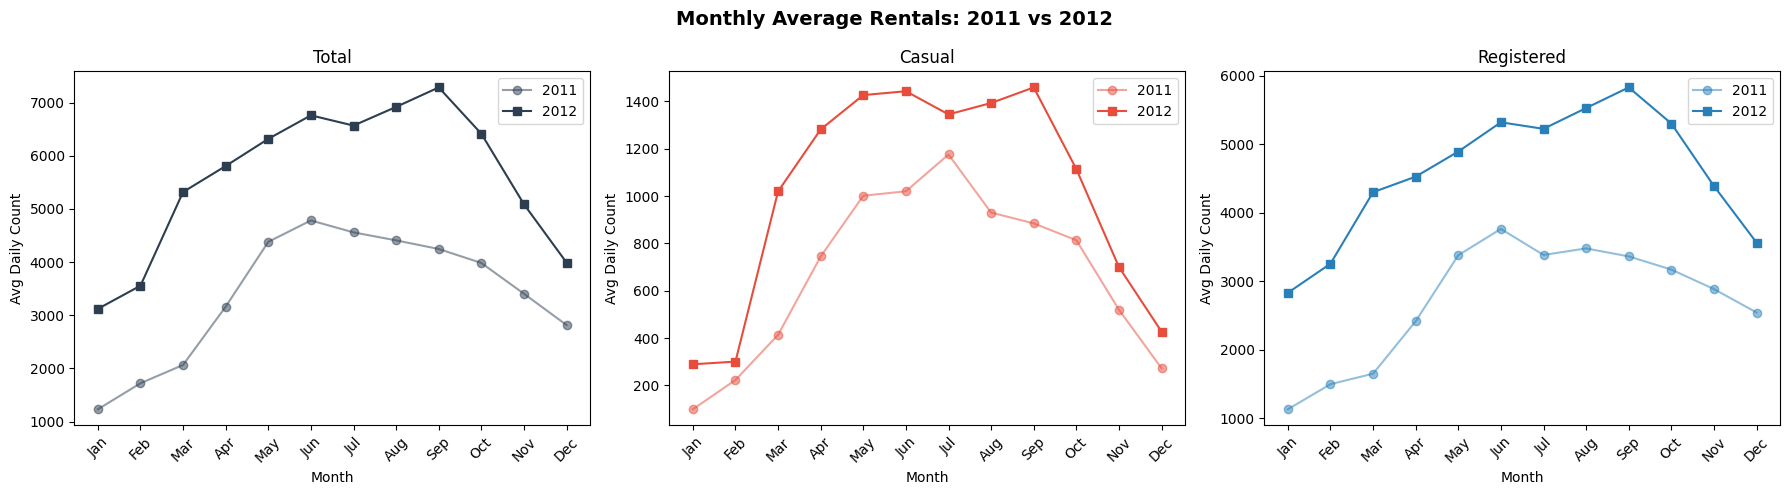

In [16]:
#Daily Rental Patterns Over Time

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Monthly Average Rentals: 2011 vs 2012', fontsize=14, fontweight='bold')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, (col, title, color) in enumerate([('cnt', 'Total', '#2c3e50'),
                                           ('casual', 'Casual', '#e74c3c'),
                                           ('registered', 'Registered', '#2980b9')]):
    monthly = day_df.groupby(['yr', 'mnth'])[col].mean().unstack(0)
    axes[i].plot(monthly.index, monthly[0], 'o-', color=color, alpha=0.5, label='2011')
    axes[i].plot(monthly.index, monthly[1], 's-', color=color, label='2012')
    axes[i].set_title(title)
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Avg Daily Count')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, rotation=45)
    axes[i].legend()

plt.tight_layout()
plt.show()

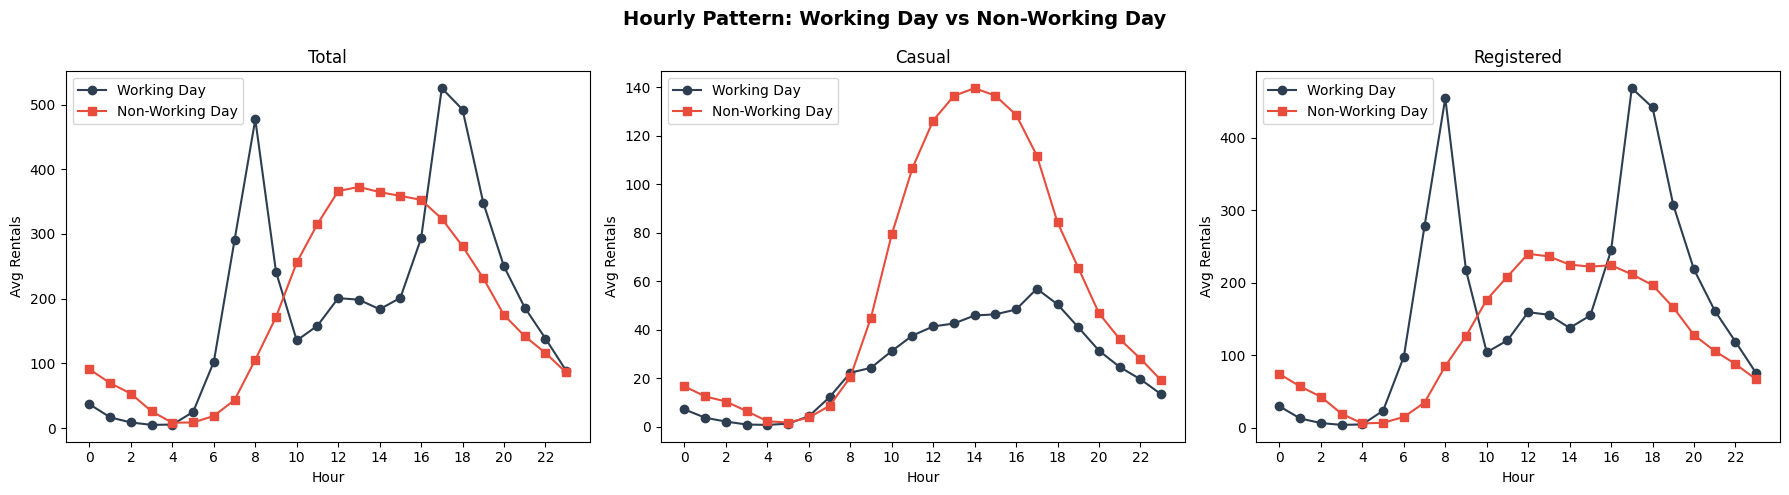

WEATHER IMPACT — % DROP FROM CLEAR
  cnt          | Mist      : -17.2%
  cnt          | Light Rain: -63.0%
  casual       | Mist      : -28.7%
  casual       | Light Rain: -80.8%
  registered   | Mist      : -14.4%
  registered   | Light Rain: -58.7%

SEASON COMPARISON — AVG DAILY RENTALS
  cnt          | Best: Fall (5644)  Worst: Spring (2604)
  casual       | Best: Fall (1203)  Worst: Spring (335)
  registered   | Best: Fall (4442)  Worst: Spring (2269)


In [17]:
# Hourly patterns — Workday vs Weekend 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hourly Pattern: Working Day vs Non-Working Day', fontsize=14, fontweight='bold')

for i, (col, title) in enumerate([('cnt', 'Total'), ('casual', 'Casual'), ('registered', 'Registered')]):
    workday = hour_df[hour_df['workingday'] == 1].groupby('hr')[col].mean()
    weekend = hour_df[hour_df['workingday'] == 0].groupby('hr')[col].mean()
    axes[i].plot(workday.index, workday.values, 'o-', color='#2c3e50', label='Working Day')
    axes[i].plot(weekend.index, weekend.values, 's-', color='#e74c3c', label='Non-Working Day')
    axes[i].set_title(title)
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Avg Rentals')
    axes[i].set_xticks(range(0, 24, 2))
    axes[i].legend()

plt.tight_layout()
plt.show()

# Print percentage drops
print("=" * 60)
print("WEATHER IMPACT — % DROP FROM CLEAR")
print("=" * 60)
for col in ['cnt', 'casual', 'registered']:
    weather = day_df.groupby('weathersit')[col].mean()
    clear = weather[1]
    for w, label in [(2, 'Mist'), (3, 'Light Rain')]:
        drop = (clear - weather[w]) / clear * 100
        print(f"  {col:12s} | {label:10s}: -{drop:.1f}%")

print("\n" + "=" * 60)
print("SEASON COMPARISON — AVG DAILY RENTALS")
print("=" * 60)
for col in ['cnt', 'casual', 'registered']:
    seasonal = day_df.groupby('season')[col].mean()
    best = season_labels[seasonal.values.argmax()]
    worst = season_labels[seasonal.values.argmin()]
    print(f"  {col:12s} | Best: {best} ({seasonal.max():.0f})  Worst: {worst} ({seasonal.min():.0f})")


# Light rain reduces casual rentals by 80.8% and registered by 58.7% compared to clear weather.
